# BaClasT — Training and Evaluation Notebook

In [ ]:
# Load the k-mer feature matrix from cache, or compute from raw FASTAs on first run.
# Each genome is represented as a 256-element vector of tetramer (4-mer) frequencies.
import json
from pathlib import Path
import numpy as np
from src.classifier.features import all_kmers, load_dataset

vocab = all_kmers(4)
cache = Path("cache")

if cache.exists() and (cache / "X.npy").exists():
    X = np.load(cache / "X.npy")
    y = np.load(cache / "y.npy")
    labels = json.loads((cache / "labels.json").read_text())
    print(f"Loaded from cache: {X.shape[0]} genomes, {len(labels)} classes: {labels}")
else:
    X, y, labels = load_dataset("genomes/", 4, vocab)
    cache.mkdir(exist_ok=True)
    np.save(cache / "X.npy", X)
    np.save(cache / "y.npy", y)
    (cache / "labels.json").write_text(json.dumps(labels))
    print(f"Loaded {X.shape[0]} genomes, {len(labels)} classes: {labels}")
    print(f"Cached to {cache}/")

Loaded from cache: 1109 genomes, 7 classes: ['Acinetobacter_baumannii', 'Enterobacter_cloacae', 'Enterococcus_faecium', 'Klebsiella_pneumoniae', 'Other', 'Pseudomonas_aeruginosa', 'Staphylococcus_aureus']


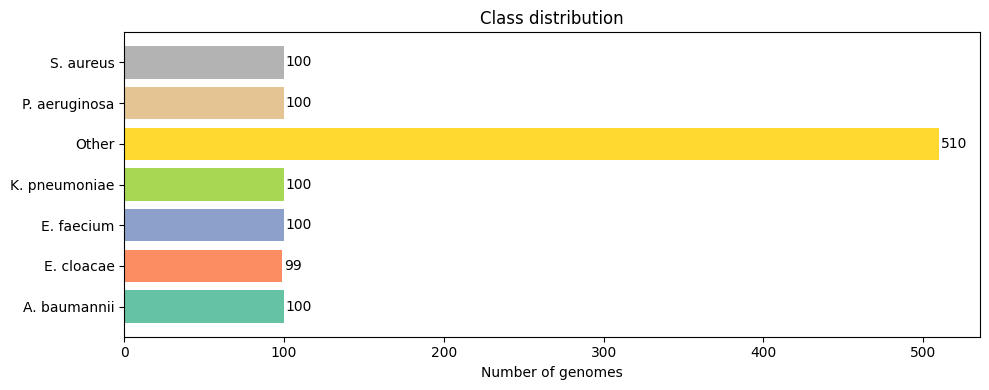

In [2]:
# How many genomes per class? Check for imbalance before training.
%matplotlib inline
import matplotlib.pyplot as plt

counts = [np.sum(y == i) for i in range(len(labels))]
short = [f"{l.split('_')[0][0]}. {l.split('_')[-1]}" if "_" in l else l for l in labels]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(short, counts, color=plt.cm.Set2(np.linspace(0, 1, len(labels))))
ax.set_xlabel("Number of genomes")
ax.set_title("Class distribution")
for bar, c in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, str(c), va="center")
plt.tight_layout()
plt.show()

Train: 887, Test: 222


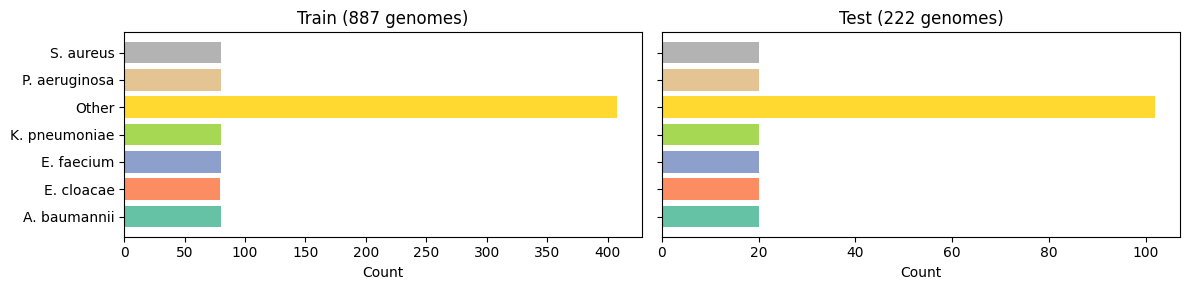

In [3]:
# Stratified 80/20 split ensures each species has proportional representation
# in both sets. random_state=42 makes this reproducible.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# Verify stratification preserved class proportions
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, data, title in [(axes[0], y_train, "Train"), (axes[1], y_test, "Test")]:
    c = [np.sum(data == i) for i in range(len(labels))]
    ax.barh(short, c, color=plt.cm.Set2(np.linspace(0, 1, len(labels))))
    ax.set_title(f"{title} ({len(data)} genomes)")
    ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

In [4]:
# Train a Random Forest with 200 trees and balanced class weights.
# Balanced weights automatically upweight minority classes so the model
# doesn't just predict the most common species. Uses all CPU cores.
from src.classifier.model import train_classifier

clf = train_classifier(X_train, y_train)
print(f"Trained: {clf.n_estimators} trees, {clf.n_features_in_} features, {len(clf.classes_)} classes")

Trained: 200 trees, 256 features, 7 classes


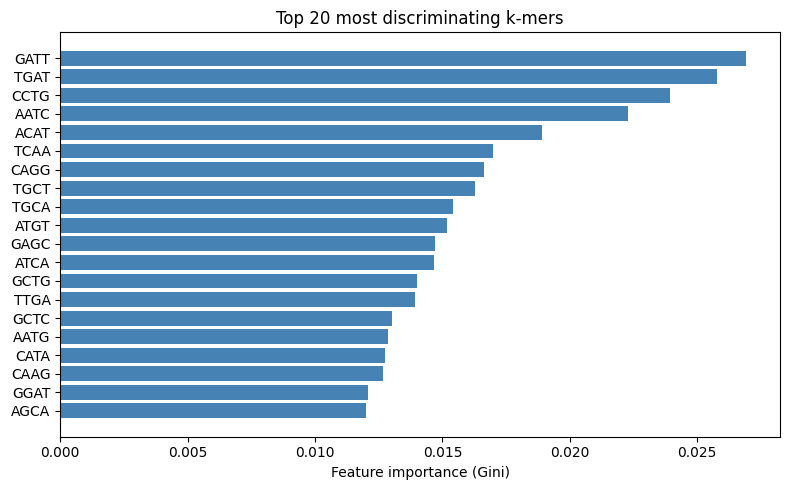

In [5]:
# Which k-mers matter most? Top 20 by Random Forest feature importance.
# These are the tetramers whose frequencies are most discriminating between species.
importances = clf.feature_importances_
top_idx = np.argsort(importances)[-20:]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([vocab[i] for i in top_idx], importances[top_idx], color="steelblue")
ax.set_xlabel("Feature importance (Gini)")
ax.set_title("Top 20 most discriminating k-mers")
plt.tight_layout()
plt.show()


Accuracy: 0.9955

                         precision    recall  f1-score   support

Acinetobacter_baumannii       1.00      1.00      1.00        20
   Enterobacter_cloacae       1.00      0.95      0.97        20
   Enterococcus_faecium       1.00      1.00      1.00        20
  Klebsiella_pneumoniae       1.00      1.00      1.00        20
                  Other       0.99      1.00      1.00       102
 Pseudomonas_aeruginosa       1.00      1.00      1.00        20
  Staphylococcus_aureus       1.00      1.00      1.00        20

               accuracy                           1.00       222
              macro avg       1.00      0.99      1.00       222
           weighted avg       1.00      1.00      1.00       222

Confusion matrix:
[[ 20   0   0   0   0   0   0]
 [  0  19   0   0   1   0   0]
 [  0   0  20   0   0   0   0]
 [  0   0   0  20   0   0   0]
 [  0   0   0   0 102   0   0]
 [  0   0   0   0   0  20   0]
 [  0   0   0   0   0   0  20]]


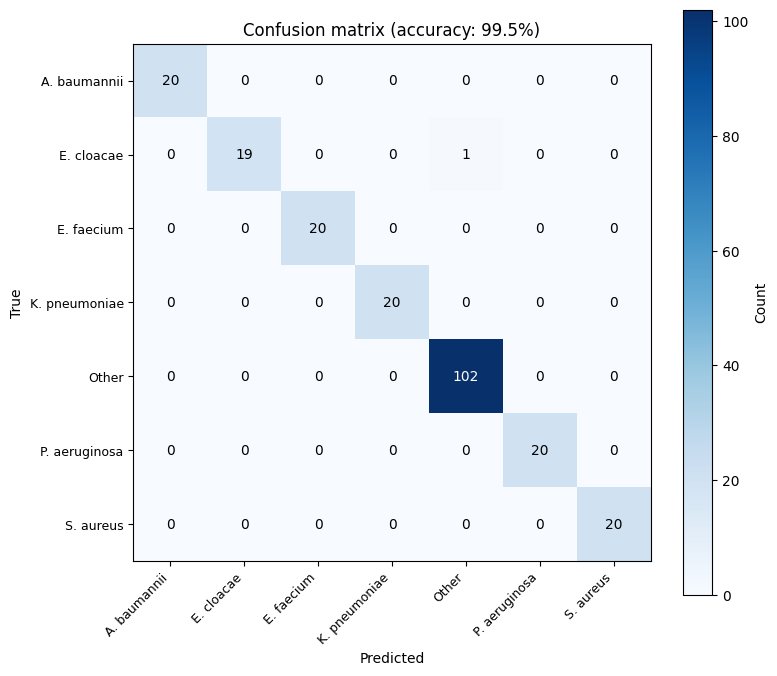

In [6]:
# Evaluate on held-out test set. Prints accuracy, per-class metrics, and
# confusion matrix. The confusion matrix shows where misclassifications happen —
# off-diagonal entries are errors.
from src.classifier.model import evaluate

results = evaluate(clf, X_test, y_test, labels)

# Confusion matrix heatmap
cm = results["confusion_matrix"]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(short, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(short, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        color = "white" if cm[i, j] > cm.max() * 0.6 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)
plt.colorbar(im, ax=ax, label="Count")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (accuracy: {results['accuracy']:.1%})")
plt.tight_layout()
plt.show()

CV accuracy: 0.9982 +/- 0.0022


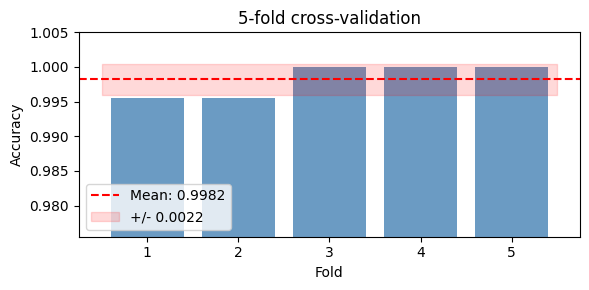

In [7]:
# 5-fold stratified cross-validation on ALL data (not just the train split).
# Gives a more robust accuracy estimate than a single 80/20 split.
# Each fold trains on 80% and tests on 20%, rotating through the data.
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
print(f"CV accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

# Visualise fold-by-fold scores
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), scores, color="steelblue", alpha=0.8)
ax.axhline(scores.mean(), color="red", linestyle="--", label=f"Mean: {scores.mean():.4f}")
ax.fill_between([0.5, 5.5], scores.mean() - scores.std(), scores.mean() + scores.std(),
                alpha=0.15, color="red", label=f"+/- {scores.std():.4f}")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("5-fold cross-validation")
ax.set_ylim(min(scores) - 0.02, 1.005)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Compute the centroid (mean k-mer vector) for each species.
# These represent the "typical" k-mer profile for each class.
# The distance threshold is calibrated at the 99th percentile of
# within-class distances — anything further is flagged out-of-distribution.
from src.classifier.model import compute_centroids, compute_distance_threshold

centroids = compute_centroids(X_train, y_train, labels)
threshold = compute_distance_threshold(X_train, y_train, centroids, labels)
print(f"OOD distance threshold (99th percentile): {threshold:.6f}")

OOD distance threshold (99th percentile): 0.064824


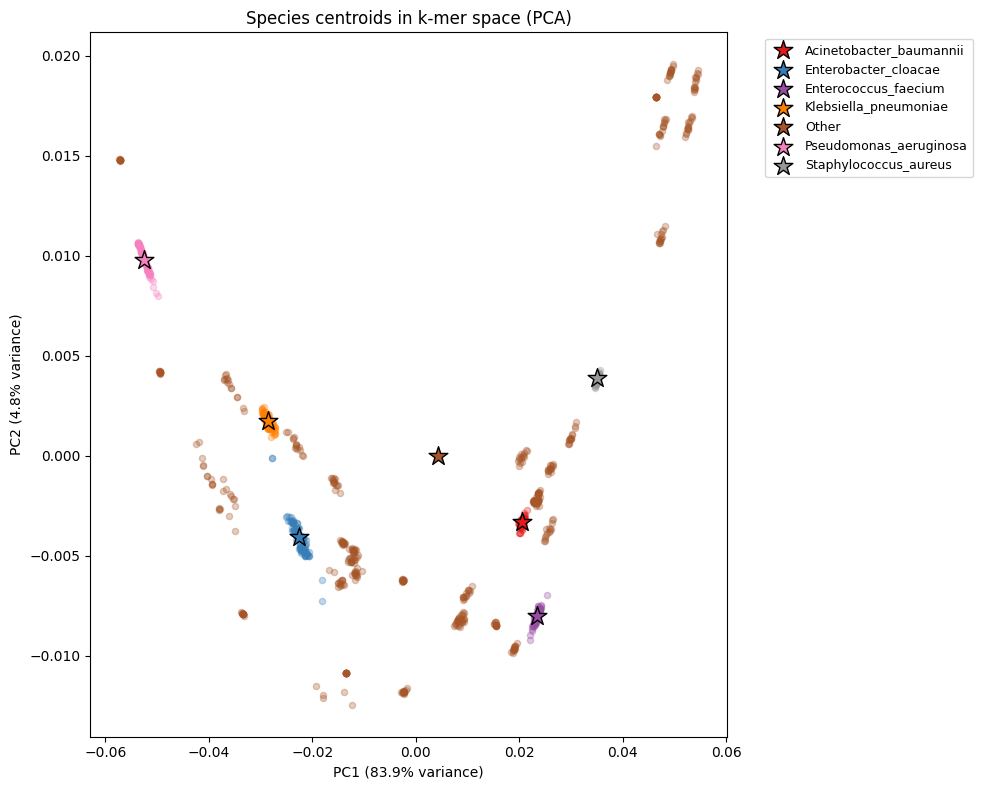

In [9]:
# PCA projection of all genomes into 2D. Individual genomes are faded dots,
# centroids are stars. Shows how species cluster in k-mer space and which
# species overlap — this is how the CLASSIFIER sees the data, not phylogeny.
%matplotlib inline
from src.classifier.viz import plot_centroids

plot_centroids(centroids, X, y, labels)

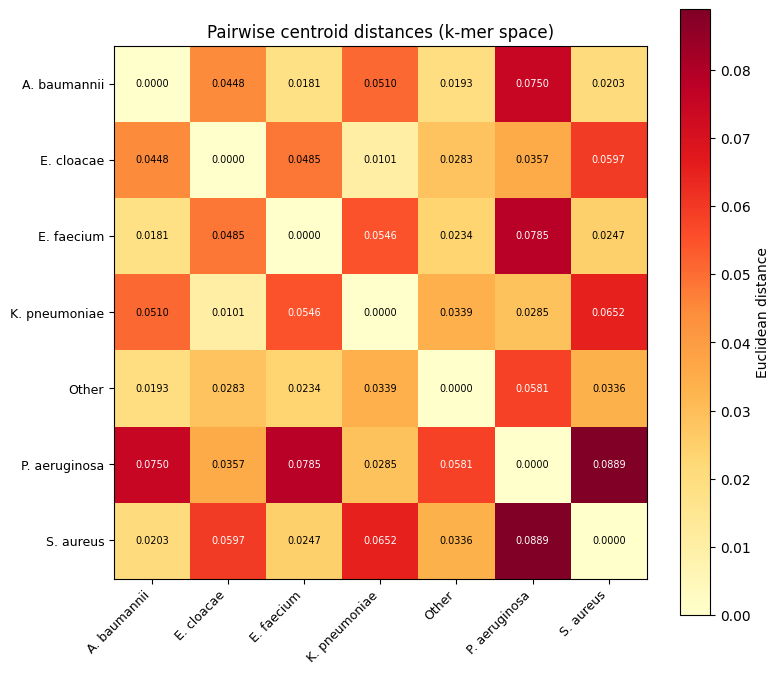

In [10]:
# Pairwise Euclidean distance between all species centroids in the full
# 256-dimensional k-mer space. Small values = species the classifier may
# confuse. Compare with the confusion matrix above.
from src.classifier.viz import plot_centroid_distances

plot_centroid_distances(centroids)

In [11]:
# Save everything needed for prediction into a single .pkl file:
# the classifier, vocabulary, centroids, OOD threshold, and metadata.
from src.classifier.model import save_model
import joblib

save_model(clf, labels, 4, vocab, "model.pkl",
           centroids=centroids, distance_threshold=threshold)

# Patch in actual training genome count
payload = joblib.load("model.pkl")
payload["n_genomes"] = X_train.shape[0]
joblib.dump(payload, "model.pkl")
print(f"Model saved to model.pkl ({X_train.shape[0]} training genomes)")

Model saved to model.pkl (887 training genomes)


## Prediction

In [22]:
# Load a saved model and classify an unknown genome.
# Reports both the RF prediction + confidence AND the centroid distance
# to detect out-of-distribution genomes that don't belong to any trained class.
import numpy as np
from src.classifier.features import genome_to_vector
from src.classifier.model import load_model, novelty_score

payload = load_model("model.pkl")
clf = payload["classifier"]
vocab = payload["kmer_vocab"]
k = payload["k"]
labels = payload["label_names"]
centroids = payload["centroids"]
threshold = payload["distance_threshold"]

# ----- CHANGE THIS PATH to your query genome -----
vec = genome_to_vector("./phageWA/ATCC_6538.fasta", k, vocab)
# --------------------------------------------------

X_q = np.array([vec])
pred = clf.predict(X_q)[0]
proba = clf.predict_proba(X_q)[0]
nearest, dist = novelty_score(vec, centroids)

species = labels[pred]
confidence = proba[pred] * 100
ood = "OUT-OF-DISTRIBUTION" if dist > threshold else "in-distribution"

print(f"Predicted: {species}  (RF confidence: {confidence:.1f}%)")
print(f"Nearest centroid: {nearest}  (distance: {dist:.6f}, threshold: {threshold:.6f})  {ood}")
print()
for name, p in sorted(zip(labels, proba), key=lambda x: -x[1]):
    bar = "#" * int(p * 40)
    print(f"  {name:30s} {p*100:5.1f}%  |{bar}")

Predicted: Staphylococcus_aureus  (RF confidence: 100.0%)
Nearest centroid: Staphylococcus_aureus  (distance: 0.000591, threshold: 0.064824)  in-distribution

  Staphylococcus_aureus          100.0%  |########################################
  Acinetobacter_baumannii          0.0%  |
  Enterobacter_cloacae             0.0%  |
  Enterococcus_faecium             0.0%  |
  Klebsiella_pneumoniae            0.0%  |
  Other                            0.0%  |
  Pseudomonas_aeruginosa           0.0%  |
